In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plt_config

In [2]:
try:
    x0 = np.load("../scripts/saved_variables/module0/x0_00.npy")
    inputs = np.load("../scripts/saved_variables/module0/inputs_00.npy")
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


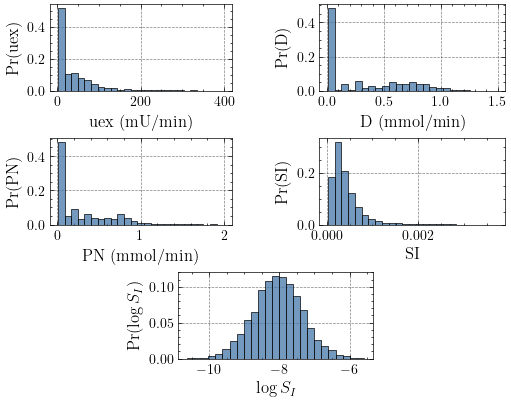

In [3]:
states = [
    "G (mmol/L)",
    "I (mU/L)",
    "Q (mU/L)",
    "P1 (mmol)",
    "P2 (mmol)",
    "P (mmol)",
    "uen (mU/min)",
]
states_short = ["G", "I", "Q", "P1", "P2", "P", "uen"]
input_labels = ["uex (mU/min)", "D (mmol/min)", "PN (mmol/min)", "SI"]
input_short = ["uex", "D", "PN", "SI"]

fig = plt.figure(figsize=(5.1, 4))
gs = fig.add_gridspec(nrows=3, ncols=4, height_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[2, 1:3])

for i, ax in enumerate([ax1, ax2, ax3, ax4], start=0):
    sns.histplot(data=inputs[i, :], bins=25, stat="probability", ax=ax)
    ax.set_xlabel(input_labels[i])
    ax.set_ylabel(f"Pr({input_short[i]})")

sns.histplot(data=np.log(inputs[-1, :]), bins=25, stat="probability", ax=ax5)
ax5.set_xlabel(r"$\log S_I$")
ax5.set_ylabel(r"Pr($\log S_I$)")
plt.show()
fig.savefig("figures/5_1.pdf", format="pdf")

In [4]:
print("Mean inputs and parameters: \n", np.mean(inputs, axis=1))
print("Range of inputs and parameters: \n", np.ptp(inputs, axis=1))
print("Min of inputs and parameters: \n", np.min(inputs, axis=1))
print("Max of inputs and parameters: \n", np.max(inputs, axis=1))

Mean inputs and parameters: 
 [3.21716000e+01 3.16351500e-01 2.72976000e-01 4.09491489e-04]
Range of inputs and parameters: 
 [3.96000000e+02 1.48500000e+00 1.98000000e+00 3.70318695e-03]
Min of inputs and parameters: 
 [2.00000000e+00 7.50000000e-03 1.00000000e-02 2.40541004e-05]
Max of inputs and parameters: 
 [3.98000000e+02 1.49250000e+00 1.99000000e+00 3.72724105e-03]


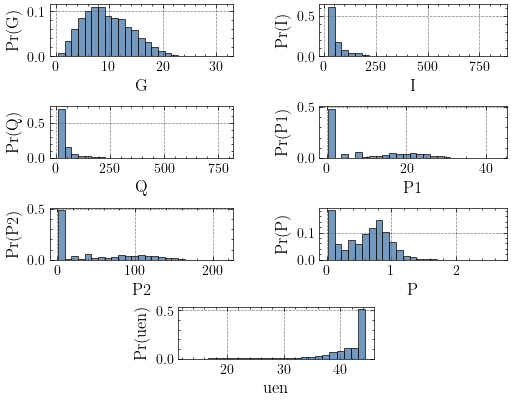

In [5]:
fig = plt.figure(figsize=(5.1, 4))
gs = fig.add_gridspec(nrows=4, ncols=4, height_ratios=[1, 1, 1, 1])

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4])
ax7 = fig.add_subplot(gs[3, 1:3])

for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7], start=0):
    sns.histplot(data=x0[i,:], bins=25, stat="probability", ax=ax)
    ax.set_xlabel(states_short[i])
    ax.set_ylabel(f"Pr({states_short[i]})")
plt.show()
fig.savefig("figures/5_2.pdf", format="pdf")

In [11]:
print("Median initial states: \n", np.median(x0, axis=1))
print("Log10 of Medians: \n", np.log10(np.median(x0, axis=1)))
print("Range of initial states: \n", np.ptp(x0, axis=1))
print("Min of initial states: \n", np.min(x0, axis=1))
print("Max of initial states: \n", np.max(x0, axis=1))
print("Initial Covariance: \n", np.diag(np.cov(x0, rowvar=True)))

Median initial states: 
 [ 9.11700839 29.38877821 16.33465525  3.67887235 18.39436177  0.6525
 43.72915887]
Log10 of Medians: 
 [ 0.95985235  1.46818153  1.21310997  0.56571472  1.26468472 -0.18541948
  1.64077112]
Range of initial states: 
 [ 31.18229432 820.20189444 769.34320389  42.84804271 214.24021357
   2.635       31.40073638]
Min of initial states: 
 [4.25705048e-01 1.97783258e+01 1.06371327e+01 2.16404256e-01
 1.08202128e+00 1.75000000e-02 1.29633736e+01]
Max of initial states: 
 [ 31.60799937 839.98022023 779.9803366   43.06444697 215.32223485
   2.6525      44.36411   ]
Initial Covariance: 
 [1.99780594e+01 4.88557491e+03 3.47502377e+03 1.05124286e+02
 2.62810715e+03 1.39061879e-01 1.41322349e+01]
